<a href="https://colab.research.google.com/github/jadhavsiya481-hash/Python-Basic-Projects/blob/main/Assignment_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ford_car_dataset.csv")

In [2]:
df.head(10)
df.tail()
df.shape
df.dtypes
df.info()

#Dataset contains numerical and categorical columns.
#price is the target variable.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [3]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

# isnull checks missing values. And duplicate rows are removed using drop_duplicates().

In [6]:
df.describe()
print("Mean")
print(df[['price','mileage','year']].mean())
print("Median")
print(df[['price','mileage','year']].median())
print("Minimum")
print(df[['price','mileage','year']].min())
print("Maximum")
print(df[['price','mileage','year']].max())

Mean
price      12269.556310
mileage    23381.146362
year        2016.862396
dtype: float64


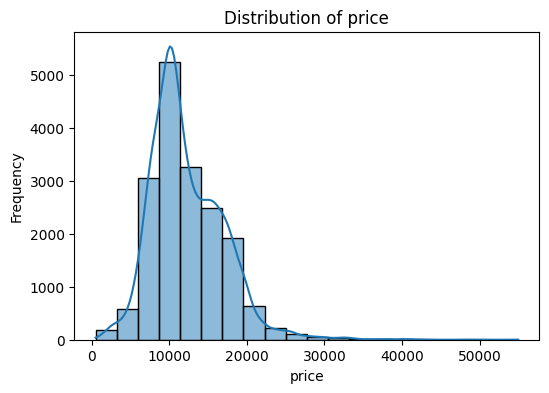

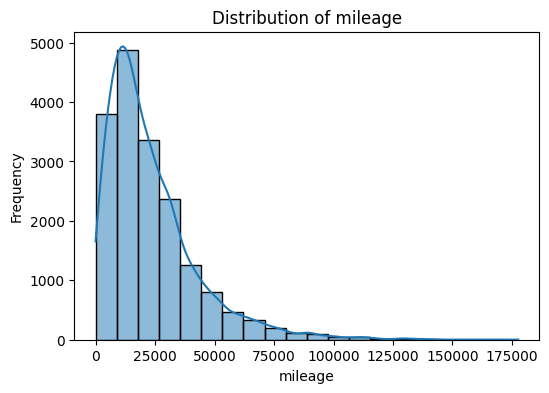

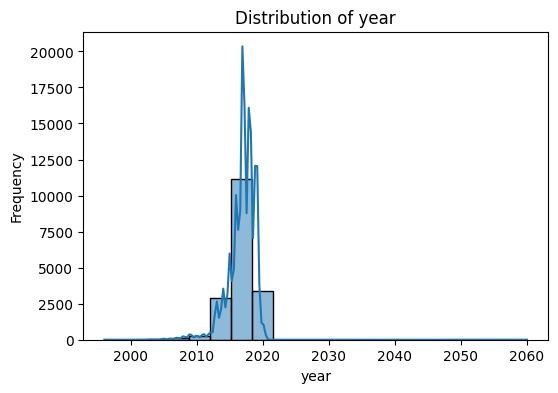

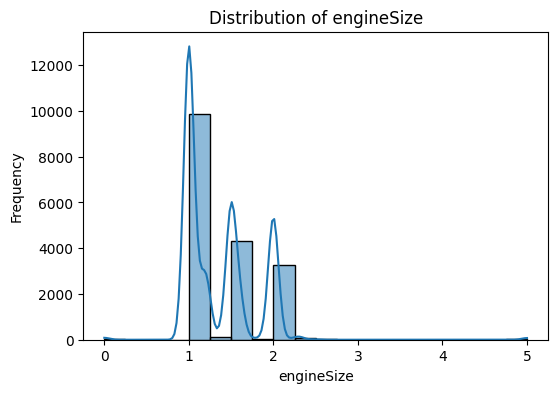

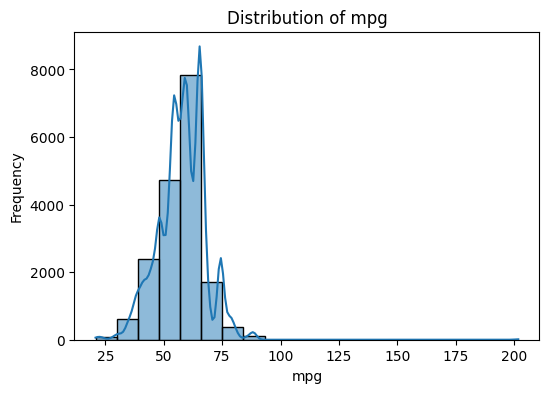

In [7]:
numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Helps find if data is normally dist. or skewed.

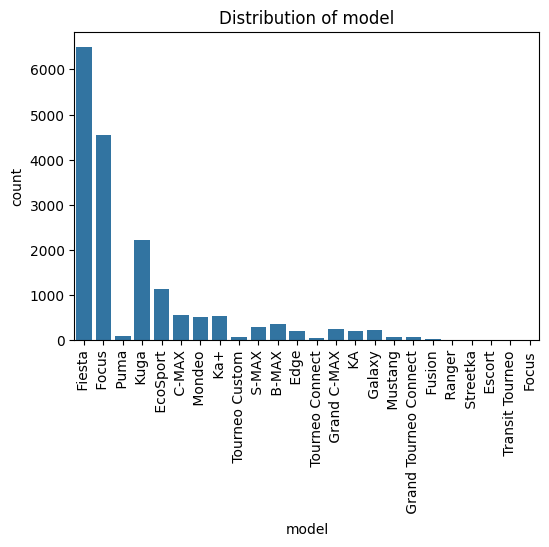

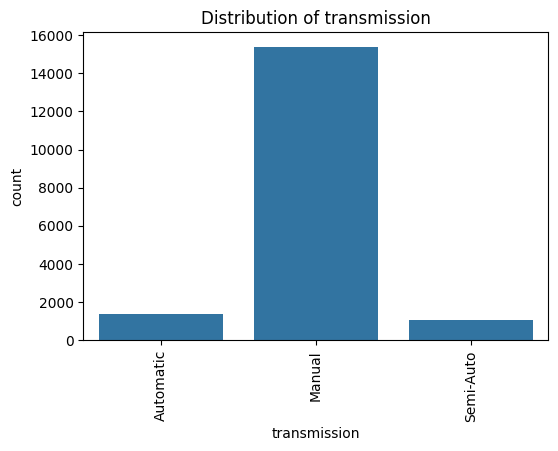

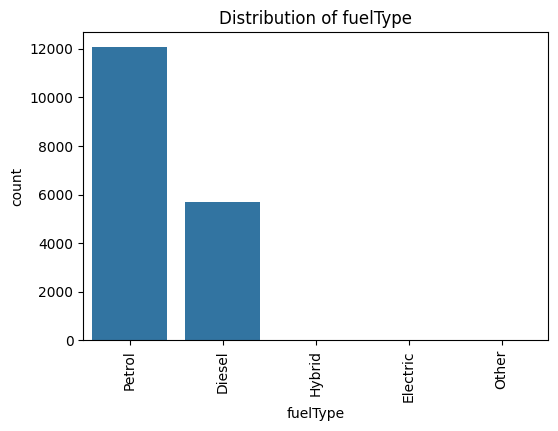

In [9]:
categorical_cols = ['model', 'transmission', 'fuelType']
for col in categorical_cols:
  plt.figure(figsize=(6, 4))
  sns.countplot(x=df[col])
  plt.title(f'Distribution of {col}')
  plt.xticks(rotation=90)
  plt.show()

  # Countplot helps identify the most common categories.

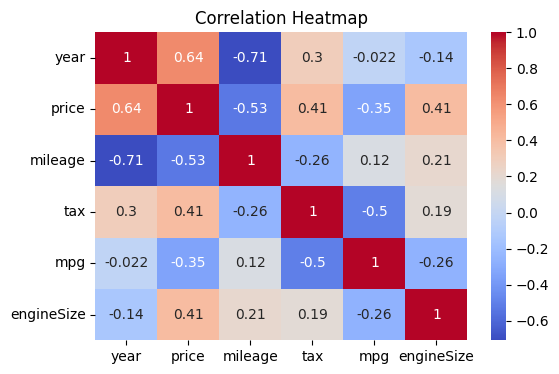

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Features have a high positive and negative correlation with the price.

In [11]:
X = df.drop('price', axis=1)
y = df['price']
print('Independent Features:')
print(X.columns.tolist())
print('\nDependent Features:')
print(y.name)

# price is the target variable.
# other columns are input features.

Independent Features:
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Dependent Features:
price


In [15]:
print('Before Encoding')
print(df[['fuelType','transmission']].head())
encoded_df = pd.get_dummies(df, columns=['model','fuelType', 'transmission'],drop_first=True)
print('\nAfter Encoding')
print(encoded_df.head())


Before Encoding
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False          Fal

In [16]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['year','mileage','tax','mpg','engineSize']
scaler = StandardScaler()
encoded_df[numeric_features] = scaler.fit_transform(encoded_df[numeric_features])
print(encoded_df[numeric_features].head())


       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


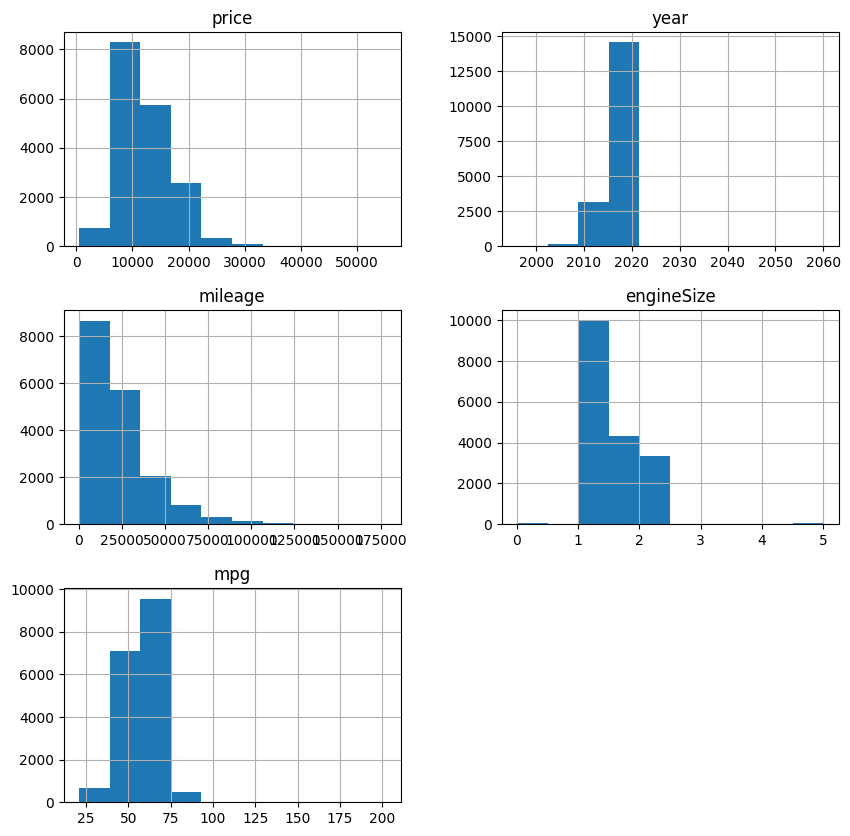

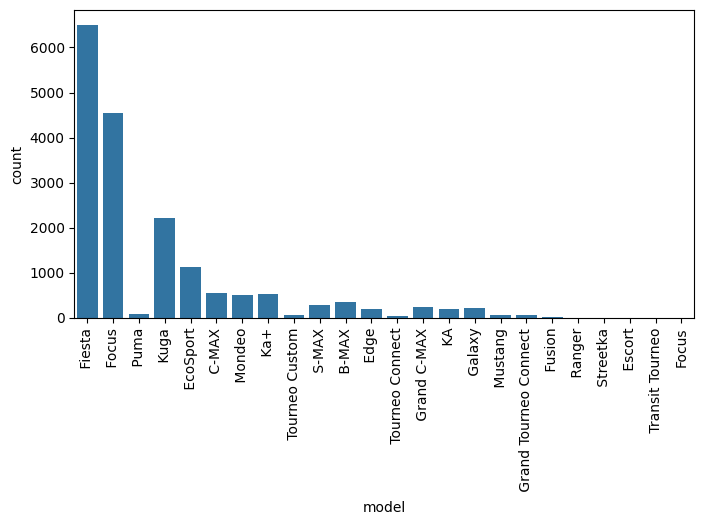

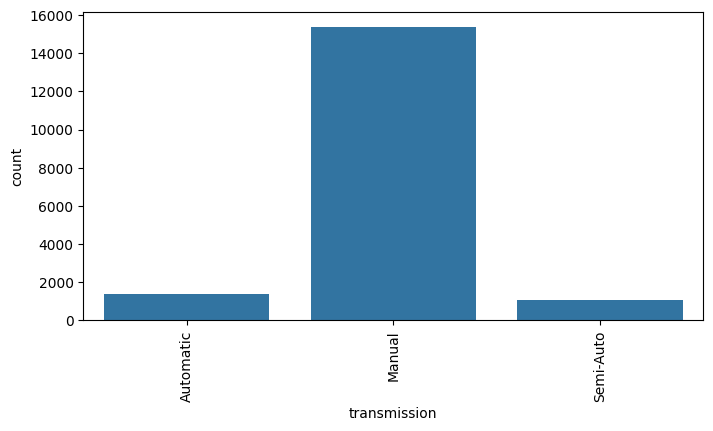

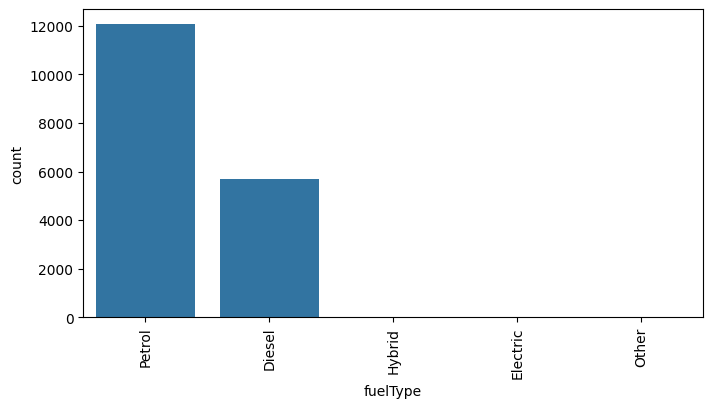

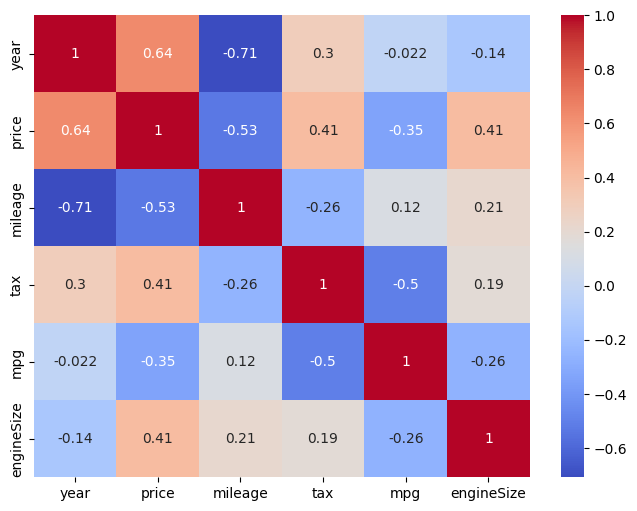

       year  price   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059  12000 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393  14000 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059  13000 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726  17500 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726  16500 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0            False        False          False  ...                   False   
1            False        False          False  ...                   False   
2            False        False          False  ...                   False   
3            False        False          False  ...                   False   
4            False        False          False  ...                   False   

   model_ Tourneo Custom  model_ Transit Tourneo  model_

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('ford_car_dataset.csv')

df = df.drop_duplicates()

print(df.isnull().sum())
df[['price','year','mileage','engineSize','mpg']].hist(figsize=(10, 10))
plt.show()

for col in ['model','transmission','fuelType']:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

X = df.drop('price', axis=1)
y = df['price']

df = pd.get_dummies(df, columns=['model','fuelType', 'transmission'],drop_first=True)

scaler = StandardScaler()
cols = ['year','mileage','engineSize','mpg','tax']
df[cols] = scaler.fit_transform(df[cols])
print(df.head())